# ARCHS4 saturation (k=1728) — LV–trait association recovery vs coverage

`phenoplier shortcut gls` was run for the ARCHS4 saturation models at fixed
**k = 1728** LVs across coverage fractions `rs ∈ {1,5,10,25,50,75}` and seeds
`{1,2,3}` — **17 models** (`rs1/seed1` is missing). This notebook traces how many
LV–trait associations are recovered as more of the compendium is used.

> **Biomedical subset only.** Every run used `--trait-filter biomedical`, so the
> 1,683 non-biomedical phenotypes are dropped before computing and all counts
> below are over the **2,366 of 4,049** biomedical traits — consistent across
> fractions, but not comparable to unfiltered runs. Launcher:
> `scripts/phenoplier/saturation_k1728/`.

Point `WS` at the workspace holding `projects/sat_rs<f>_k1728_seed<s>_CLAMPfull_bp/`
(defaults to the pico path; override with `CLAMP_PHENOPLIER_WS`).

In [1]:
%matplotlib inline
import os, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WS = Path(os.environ.get("CLAMP_PHENOPLIER_WS", "/pividori_lab/phenoplier_workspace"))
projects = sorted((WS / "projects").glob("sat_rs*_k1728_seed*_CLAMPfull_bp"))
pat = re.compile(r"sat_rs(\d+)_k1728_seed(\d+)_CLAMPfull_bp")

rows = []
for p in projects:
    m = pat.search(p.name)
    rs, seed = int(m.group(1)), int(m.group(2))
    f = p / "results" / "gls" / "phenoplier" / "gls-summary-phenomexcan.tsv.gz"
    if not f.exists():
        print(f"  (missing summary) rs{rs} seed{seed}")
        continue
    d = pd.read_csv(f, sep="\t", low_memory=False)
    sig = d["fdr"] < 0.05
    deg = d["lv_degenerate"].fillna(False).astype(bool) if "lv_degenerate" in d else pd.Series(False, index=d.index)
    rows.append({
        "rs": rs, "seed": seed,
        "n_phenotypes": d["phenotype"].nunique(), "n_LVs": d["lv"].nunique(),
        "n_sig_assoc": int(sig.sum()),
        "n_traits_recovered": int(d.loc[sig, "phenotype"].nunique()),
        "n_LVs_with_sig": int(d.loc[sig, "lv"].nunique()),
        "min_pvalue": d["pvalue"].min(), "zero_pvalues": int((d["pvalue"] == 0).sum()),
        "degenerate_LVs": int(d.loc[deg, "lv"].nunique()), "NaN_fdr": int(d["fdr"].isna().sum()),
    })
res = pd.DataFrame(rows).sort_values(["rs", "seed"]).reset_index(drop=True)
print(f"{len(res)} models loaded")
res

17 models loaded


,rs,seed,n_phenotypes,n_LVs,n_sig_assoc,n_traits_recovered,n_LVs_with_sig,min_pvalue,zero_pvalues,degenerate_LVs,NaN_fdr
0,1,2,2366,1728,4574,879,1078,3.234610e-39,0,0,0
1,1,3,2366,1728,4438,888,1085,2.760180e-63,0,0,0
2,5,1,2366,1728,5591,1008,1177,6.189320e-75,0,0,0
3,5,2,2366,1728,5265,938,1201,1.810540e-55,0,1,82
4,5,3,2366,1728,4907,939,1160,4.121510e-69,0,0,0
5,10,1,2366,1728,5533,1034,1204,3.076550e-72,0,0,0
6,10,2,2366,1728,5213,991,1187,1.658270e-65,0,0,0
7,10,3,2366,1728,5441,985,1192,2.038880e-64,0,0,0
8,25,1,2366,1728,4604,939,1139,3.894190e-81,0,0,0
9,25,2,2366,1728,5495,1025,1192,3.925750e-50,0,0,0


## Saturation curves — recovery vs coverage fraction

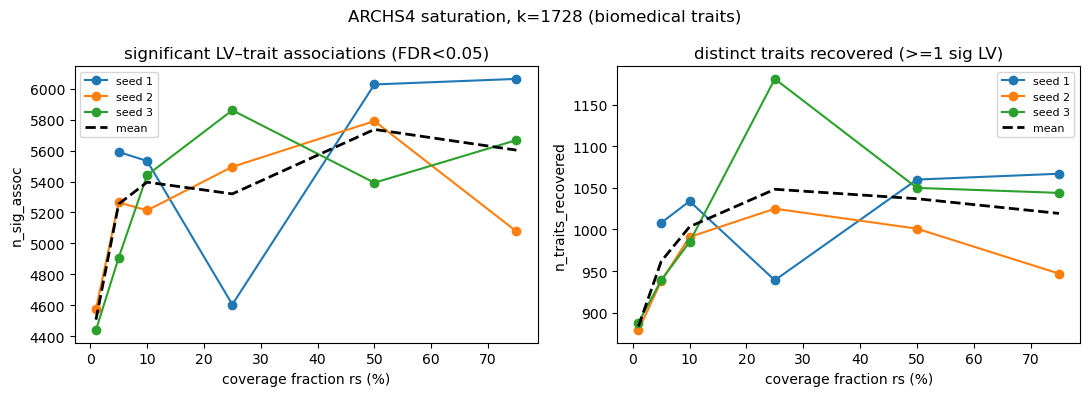

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in [
    (axes[0], "n_sig_assoc", "significant LV–trait associations (FDR<0.05)"),
    (axes[1], "n_traits_recovered", "distinct traits recovered (>=1 sig LV)"),
]:
    for seed, g in res.groupby("seed"):
        g = g.sort_values("rs")
        ax.plot(g["rs"], g[col], marker="o", label=f"seed {seed}")
    mean = res.groupby("rs")[col].mean()
    ax.plot(mean.index, mean.values, color="black", lw=2, ls="--", label="mean")
    ax.set_xlabel("coverage fraction rs (%)"); ax.set_ylabel(col)
    ax.set_title(title); ax.legend(fontsize=8)
fig.suptitle("ARCHS4 saturation, k=1728 (biomedical traits)")
fig.tight_layout(); plt.show()

## Per-model counts

`zero_pvalues` and `degenerate_LVs` should be 0 (SE-collapse guard,
phenoplier-cli#85); `n_phenotypes` should be 2,366 everywhere (the biomedical
subset).

In [3]:
piv = res.pivot_table(index="rs", columns="seed", values="n_sig_assoc")
print("significant associations by rs x seed:")
display(piv)
# sanity
bad = res[(res.n_phenotypes != 2366) | (res.zero_pvalues != 0) | (res.NaN_fdr != 0)]
print("rows failing sanity (expect none):", len(bad))
res[["rs","seed","n_phenotypes","n_LVs","n_sig_assoc","n_traits_recovered",
     "zero_pvalues","degenerate_LVs"]]

significant associations by rs x seed:


seed,1,2,3
rs,,,
1,NaN,4574.0,4438.0
5,5591.0,5265.0,4907.0
10,5533.0,5213.0,5441.0
25,4604.0,5495.0,5861.0
50,6028.0,5791.0,5392.0
75,6064.0,5077.0,5668.0


rows failing sanity (expect none): 1


,rs,seed,n_phenotypes,n_LVs,n_sig_assoc,n_traits_recovered,zero_pvalues,degenerate_LVs
0,1,2,2366,1728,4574,879,0,0
1,1,3,2366,1728,4438,888,0,0
2,5,1,2366,1728,5591,1008,0,0
3,5,2,2366,1728,5265,938,0,1
4,5,3,2366,1728,4907,939,0,0
5,10,1,2366,1728,5533,1034,0,0
6,10,2,2366,1728,5213,991,0,0
7,10,3,2366,1728,5441,985,0,0
8,25,1,2366,1728,4604,939,0,0
9,25,2,2366,1728,5495,1025,0,0


## Reproduce

See `scripts/phenoplier/saturation_k1728/README.md` (register once → GLS array
`%6` → store array `%6`, `--trait-filter biomedical`, ≤80% of pico).